
#Cluster k-medias

El objetivo de este notebook es presentar un proceso de segmentación de clientes en telecomunicaciones a partir del algoritmo k-medias
##Definición de variables - Business & data understanding

Para ello importaremos un archivo con información para esa posible segmentación.

In [12]:
install.packages("psych")
install.packages("readxl")
install.packages("reshape2")
install.packages("fpc")
install.packages("vcd")

library("cluster")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘modeltools’, ‘DEoptimR’, ‘mclust’, ‘flexmix’, ‘prabclus’, ‘diptest’, ‘robustbase’, ‘kernlab’




In [ ]:
install.packages("reshape2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘plyr’, ‘Rcpp’




In [3]:

library(readxl)
cell<-read_excel("cellsegmentation.xlsx")
str(cell)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



tibble [1,000 × 16] (S3: tbl_df/tbl/data.frame)
 $ region              : chr [1:1000] "Zona 2" "Zona 3" "Zona 3" "Zona 2" ...
 $ Edad                : num [1:1000] 44 33 52 33 30 39 22 35 59 41 ...
 $ casado              : chr [1:1000] "Married" "Married" "Married" "Unmarried" ...
 $ jubilado            : chr [1:1000] "No" "No" "No" "No" ...
 $ genero              : chr [1:1000] "M" "M" "F" "F" ...
 $ minutos_preferido   : num [1:1000] 3.7 4.4 18.15 9.45 6.3 ...
 $ adicionales         : num [1:1000] 0 20.8 18 0 0 ...
 $ equipo_dolares      : num [1:1000] 0 0 0 0 0 0 0 50.1 0 0 ...
 $ minutos_no_preferido: num [1:1000] 7.5 15.2 30.2 0 0 ...
 $ internet_gigas      : num [1:1000] 0 3.57 0 0 0 0 0 6.49 0 0 ...
 $ fijo                : num [1:1000] 0 0 0 0 0 0 1 1 1 1 ...
 $ largadistancia      : num [1:1000] 0 1 0 0 0 0 0 1 0 0 ...
 $ internetcasa        : num [1:1000] 0 0 0 0 0 0 1 1 0 0 ...
 $ numoculto           : num [1:1000] 0 1 1 0 1 1 0 1 1 0 ...
 $ facturaelect        : num [1:1000

El archivo contiene un grupo de variables demográficas (edad, género, región, casado, jubilado, y al final, ingreso en miles de pesos) y un grupo de variables de consumo: minutos a números preferidos y no preferidos, consumos adicionales, valor mensual pagado por equipo en dólares, gigabytes gastados de internet, si tiene o no tiene productos adicionales (telefonía fija, internet en casa, larga distancia, número oculto) y si recibe o no factura electrónica.

La segmentación de clientes debe hacerse por necesidades. Las variables de consumo son probablemente mejores indicadores de las necesidades que la demografía (aunque consumo, demografía y necesidades pueden estar correlacionadas). Sería interesante hacer una segmentación por consumos y luego perfilar los grupos de forma demográfica para definir estrategias.

Sin embargo, a la hora de definir una métrica de distancia, la combinación de variables de consumo binarias y escalares se dificulta.

Una posible aproximación con las variables binarias es crear una variable que indique el número de servicios adicionales que se tienen. La factura electrónica se puede dejar para perfilar como posible medio para alcanzar al segmento.

Miremos las variables escalares:

In [5]:
library(psych)
psych::describe(cell[,6:10])

,vars,n,mean,sd,median,trimmed,mad,min,max,range,skew,kurtosis,se
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
minutos_preferido,1,1000,11.72310,10.363486,8.525,9.8267500,6.115725,0.9,99.950,99.050,2.9572117,13.9418504,0.3277222
adicionales,2,1000,13.27400,16.902122,0.000,10.6609375,0.000000,0.0,173.000,173.000,1.7784607,8.2549324,0.5344920
equipo_dolares,3,1000,14.21980,19.068539,0.000,11.4369375,0.000000,0.0,77.700,77.700,0.8437261,-0.7346932,0.6030001
minutos_no_preferido,4,1000,13.78100,14.084496,12.000,11.7600000,17.791200,0.0,109.250,109.250,1.5714061,4.5682117,0.4453909
internet_gigas,5,1000,1.15839,1.971943,0.000,0.7465812,0.000000,0.0,11.195,11.195,1.5988722,1.9902226,0.0623583


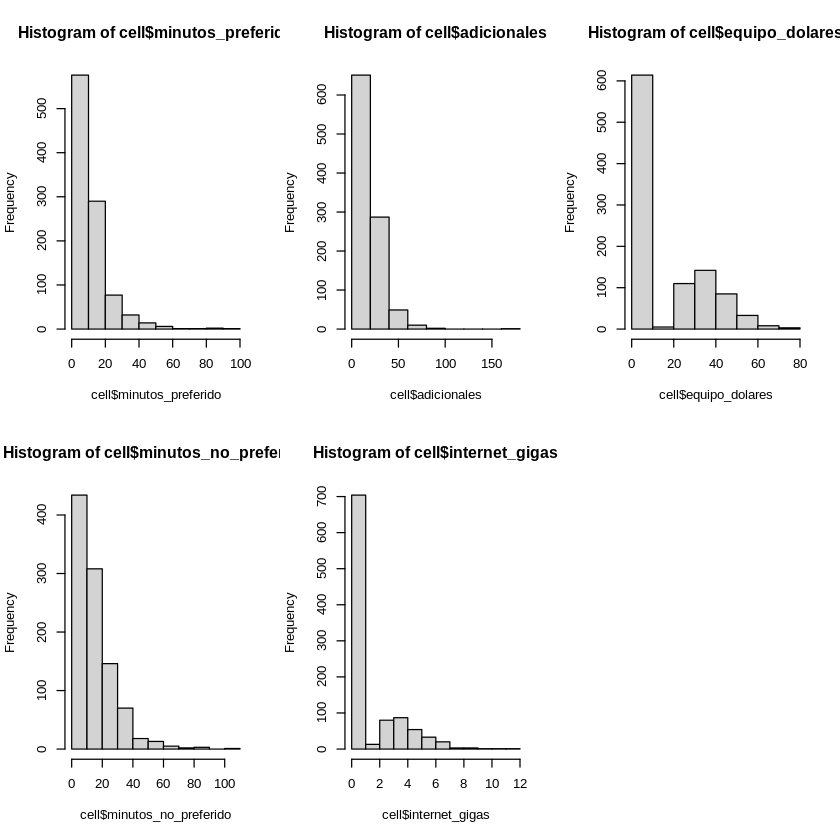

In [6]:
par(mfrow=c(2,3))
hist(cell$minutos_preferido)
hist(cell$adicionales)
hist(cell$equipo_dolares)
hist(cell$minutos_no_preferido)
hist(cell$internet_gigas)

En todas las variables (excepto minutos preferido) el mínimo es cero. De hecho en los histogramas se observa que hay porcentajes de clientes variables que simplemente no tienen el servicio o no lo consumen. En los promedios es destacable que el consumo fuera de preferidos es cercano a la tendencia central de consumo en preferidos. Las variabilidades son altas (CV´s cercanos o mayores a 100% en todas las variables), lo cual puede ser algo bueno con miras a la creación de grupos distintos. También son visibles asimetrías positivas mayores que 1 en todas las variables (excepto equipo en dólares), lo que marca la presencia de pequeños grupos de consumo extremo versus grandes grupos de bajo consumo. De hecho, las curtosis son todas grandes, (excepto por equipo en dólares) lo que implica la presencia de valores extremos.

Para disminuir la presencia de atípicos (que afectarían a k medias) puede ser una buena idea aplicar de manera adecuada un logaritmo natural a las variables.

##Data preparation

En la preparación de datos se siguieron los pasos explicados a continuación:

    Obtención de una variable que indique número de servicios adicionales.
    Aplicación de reducción de atípicos donde sea necesario (logaritmo natural de (1+x) para tener en cuenta los ceros o valores menores que cero).
    Ensamble de las variables finales en la base de datos.
    Estandarización de las variables para poder usar distancia euclídea.


In [33]:
#variable de servicios adicionales
cell$servicios<-cell$fijo+cell$largadistancia+cell$internetcasa+cell$numoculto
#reducción de atípicos
##obtener las variables a reducir
cell3<-cell[,c(6,7,9,10)]
#obtener el logaritmo de 1+x
cell4<-apply(cell3,2,log1p)
#ensamble final
cellfin<-as.data.frame(cbind(cell4,cell$servicios, cell$equipo_dolares))
colnames(cellfin)[5:6]<-c("servicios","equipo_dolares")
#estandarizar
cellfins<-as.data.frame(scale(cellfin))
#revisar descriptivos
psych::describe(cellfins)

,vars,n,mean,sd,median,trimmed,mad,min,max,range,skew,kurtosis,se
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
minutos_preferido,1,1000,-2.136678e-16,1,-0.09227459,-0.04398744,1.0327390,-2.5656867,3.529797,6.095484,0.3895140,-0.01834871,0.03162278
adicionales,2,1000,2.339340e-17,1,-0.93771415,-0.05455860,0.0000000,-0.9377141,2.166190,3.103904,0.1827006,-1.85477053,0.03162278
minutos_no_preferido,3,1000,-2.782464e-17,1,0.40969192,0.01696122,0.7231913,-1.3829559,1.903805,3.286761,-0.4748933,-1.40816240,0.03162278
internet_gigas,4,1000,-1.276691e-17,1,-0.63271393,-0.16485943,0.0000000,-0.6327139,2.818975,3.451689,1.0494119,-0.66539313,0.03162278
servicios,5,1000,9.486802e-17,1,-0.51188679,-0.07172936,1.2084767,-1.3269931,1.933432,3.260425,0.3907399,-0.78227780,0.03162278
equipo_dolares,6,1000,1.192622e-18,1,-0.74572048,-0.14594000,0.0000000,-0.7457205,3.329054,4.074775,0.8437261,-0.73469325,0.03162278


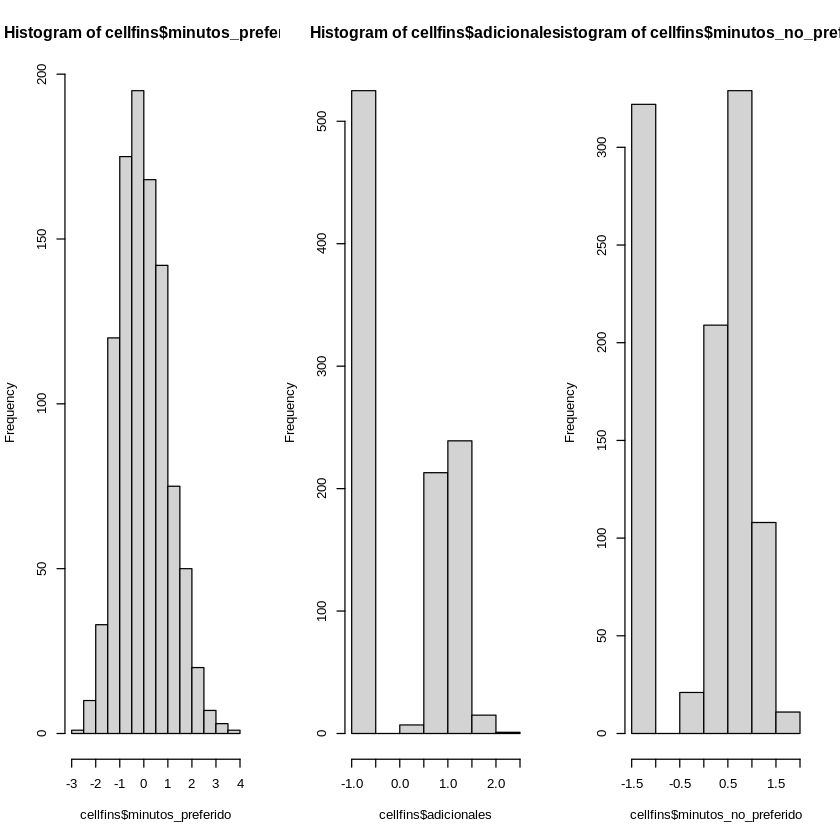

In [8]:
par(mfrow=c(1,3))
hist(cellfins$minutos_preferido)
hist(cellfins$adicionales)
hist(cellfins$minutos_no_preferido)

Al revisar se observa que la transformación fue en su mayor parte efectiva (mínimos y máximos cerca de 3 desviaciones estándar, kurtosis ya no tan positivas) aunque en algunos casos con mejores resultados que en otros (por ejemplo, en minutos preferido mejor que en minutos de no preferido).
##Modelación

En la modelación si se va a utilizar el algoritmo k-medias entonces primero se debe hacer la selección del valor de k

###Selección de k

Aunque criterios de negocio pueden aplicar en esta selección (p.e., cuántas estrategias distintas puedo manejar) también hay algunos mecanismos que permiten proponer un valor de k. El mecanismo descriptivo clásico es el gráfico de las sumas de cuadrados dentro de los clústeres frente al número de clústeres, llamado gráfico de codo. En el momento en que la curva cambia de pendiente (se ve un codo), las reducciones de cuadrados internos dejan de ser tan buenas y se puede escoger ese valor como un k sugerido. En el siguientre código vamos a hacer ese gráfico entre 2 y 15 clústeres:

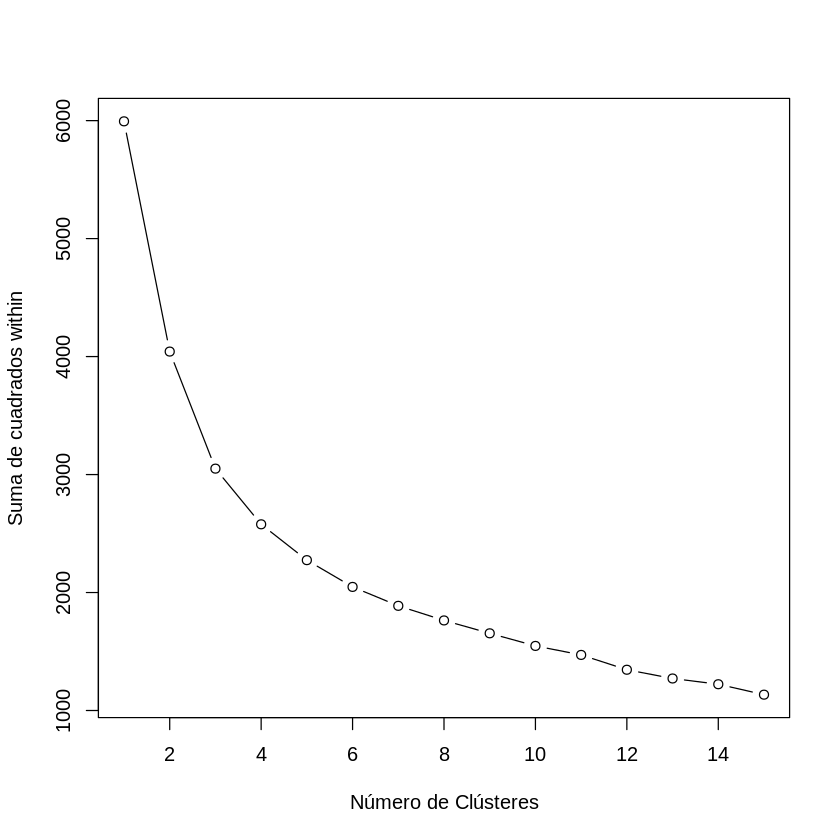

In [9]:
#utilizo una semilla para replicar resultados
set.seed(5935)
#calculo la suma de cuadrados total
wss <- (nrow(cellfins)-1)*sum(apply(cellfins,2,var))
#calculo para cada solución de clustering 
for (i in 2:15) wss[i] <- sum(kmeans(cellfins,
                              centers=i, nstart=10)$withinss)
plot(1:15, wss, type="b", xlab="Número de Clústeres",
     ylab="Suma de cuadrados within") 

In [13]:
library("cluster")
library("fpc")


In [15]:
# Evaluar usando el criterio ASW (average sillouethe width)
set.seed(2) #Para evitar aleatoriedad en los resultados
clustering.asw <- kmeansruns(cellfins,krange=2:15,criterion="asw",iter.max=100, runs= 100,critout=TRUE)
clustering.asw$bestk

2  clusters  0.3349106 
3  clusters  0.3036685 
4  clusters  0.3099519 
5  clusters  0.3208598 
6  clusters  0.3095333 
7  clusters  0.3191194 
8  clusters  0.3031483 
9  clusters  0.2898709 
10  clusters  0.3013934 
11  clusters  0.3104631 
12  clusters  0.3160116 
13  clusters  0.3119951 
14  clusters  0.314528 
15  clusters  0.3019129 


[1] 2

Este criterio sugiere 2 clústeres

El criterio sugerido por Hastie et al. (2017) es usar la estadística Gap. Obtengámosla:

In [16]:
#Evaluar con gap statistic
#mira el minimo k tal que el gap sea mayor que el gap de k+1 restado de su desviacion
gscar<-clusGap(cellfins,FUN=kmeans,K.max=15,B=60)
gscar

Clustering Gap statistic ["clusGap"] from call:
clusGap(x = cellfins, FUNcluster = kmeans, K.max = 15, B = 60)
B=60 simulated reference sets, k = 1..15; spaceH0="scaledPCA"
 --> Number of clusters (method 'firstSEmax', SE.factor=1): 5
          logW   E.logW       gap      SE.sim
 [1,] 6.702115 7.162107 0.4599918 0.006649163
 [2,] 6.506671 7.040985 0.5343140 0.011822177
 [3,] 6.353539 6.972578 0.6190398 0.006455612
 [4,] 6.257952 6.917291 0.6593390 0.008703795
 [5,] 6.203415 6.872905 0.6694894 0.007249976
 [6,] 6.166175 6.833015 0.6668396 0.008278368
 [7,] 6.091629 6.804969 0.7133404 0.007387281
 [8,] 6.137320 6.780856 0.6435365 0.008062010
 [9,] 6.016807 6.759444 0.7426372 0.007815067
[10,] 5.980584 6.742345 0.7617615 0.007602917
[11,] 5.941851 6.725879 0.7840281 0.007187430
[12,] 5.933103 6.709666 0.7765630 0.007802809
[13,] 5.909727 6.695488 0.7857604 0.008101276
[14,] 5.862582 6.682045 0.8194640 0.007484549
[15,] 5.822384 6.668778 0.8463940 0.007836128

La estadística gap sugiere como número de clústeres el valor de 5.

Como es visible los métodos pueden no coincidir, por lo que es necesario utilizar criterios empíricos para definir. Dado que el criterio de silueta vuelve a subir en 5, y 5 es una buena opción en el gráfico de codo así como en el estadístico gap, escogemos 5.
###Ejecución e interpretación de resultados

Al ejecutar k-medias es importante la estandarización, la reducción de atípicos y la definición de inicializaciones de los centros. Por ello se recomienda hacer múltiples inicializaciones para buscar el mejor resultado. En este caso vamos a inicializar 10 veces. Así mismo hay un número máximo de iteraciones permitidas (el algoritmo podría quedarse iterando por mucho tiempo, en teoría). La práctica indica que 20 iteraciones suelen ser suficientes. De todas formas pueden aumentarse en caso de que el algoritmo no converja.

Una vez ejecutado vamos a ver:

    el número de iteraciones que tomó
    el tamaño de los 5 grupos
    los centros de los grupos para la interpretación


In [17]:
#ejecución de k-means
set.seed(45390)
cellcluster<-kmeans(cellfins,centers=5,nstart=10,iter.max=20)
#tamaño de grupos
cellcluster$size

[1] 194 298  88 200 220

In [18]:
#numero de iteraciones
cellcluster$iter

[1] 7

No existen tamaños de grupo pequeños, por lo que no parece que algun atípico haya dominado o se haya apoderado de un grupo. 7 iteraciones fueron suficientes para obtener el resultado final.

In [19]:
#centros de grupos
cellcluster$centers

,minutos_preferido,adicionales,minutos_no_preferido,internet_gigas,servicios,equipo_dolares
1,-0.03836874,0.5673259,0.4088254,1.5297400,1.2737843,1.5595016
2,-0.68178663,-0.6884471,-1.3225664,-0.5568159,-0.5501804,-0.1381277
3,0.23918387,1.0666431,0.6950297,1.4778902,0.6459347,-0.7457205
4,0.34135645,1.0376426,0.5641890,-0.6327139,-0.1817687,-0.6050962
5,0.55134764,-0.9377141,0.6400557,-0.6106818,-0.4711315,-0.3397209


In [23]:
install.packages("reshape2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘plyr’, ‘Rcpp’




Using grupo as id variables



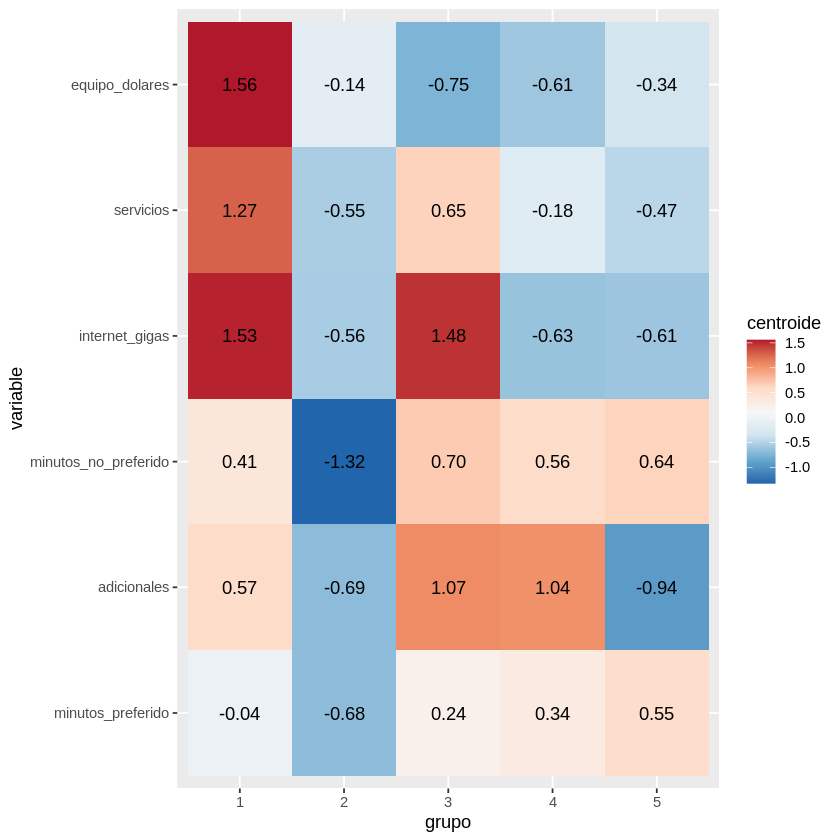

In [24]:
library(ggplot2)
library(reshape2)
centrosg<-as.data.frame(cellcluster$centers)
centrosg$grupo<-as.factor(rownames(centrosg))
centrosheat<-reshape2::melt(centrosg)
colnames(centrosheat)<-c("grupo","variable","centroide")
ggplot(centrosheat,aes(x=grupo,y=variable,fill=centroide, label=sprintf("%0.2f", round(centroide, digits=2))))+geom_tile()+scale_fill_distiller(palette="RdBu")+geom_text()

Para leer los centros, consideremos que se trata de valores estándares (algunos de ellos de logaritmos). De ese modo, valores positivos implican mayor consumo que la media, y negativos menor que la media. La magnitud indica el número de desviaciones estándar. No debemos esperar valores de 3 o más para decir que el consumo es alto, porque se trata del centro de un grupo, por lo que se esperan valores más moderados.

Basándonos en una desviación estándar tendríamos:

    El grupo 5 tiene bajo consumo de adicionales.
    El grupo 3 es de alto consumo de adicionales e internet.
    El grupo 2 es un grupo de bajo consumo, particularmente en sus minutos a no preferidos.
    El grupo 4 se caracteriza por alto consumo de adicionales.
    El grupo 1 es de alto consumo de internet, tiene combos o servicios con la empresa y paga más que el promedio por equipos.

##Perfilamiento

Una vez definidos los grupos, podemos perfilarlos demográficamente para plantear estrategias.

Loading required package: grid



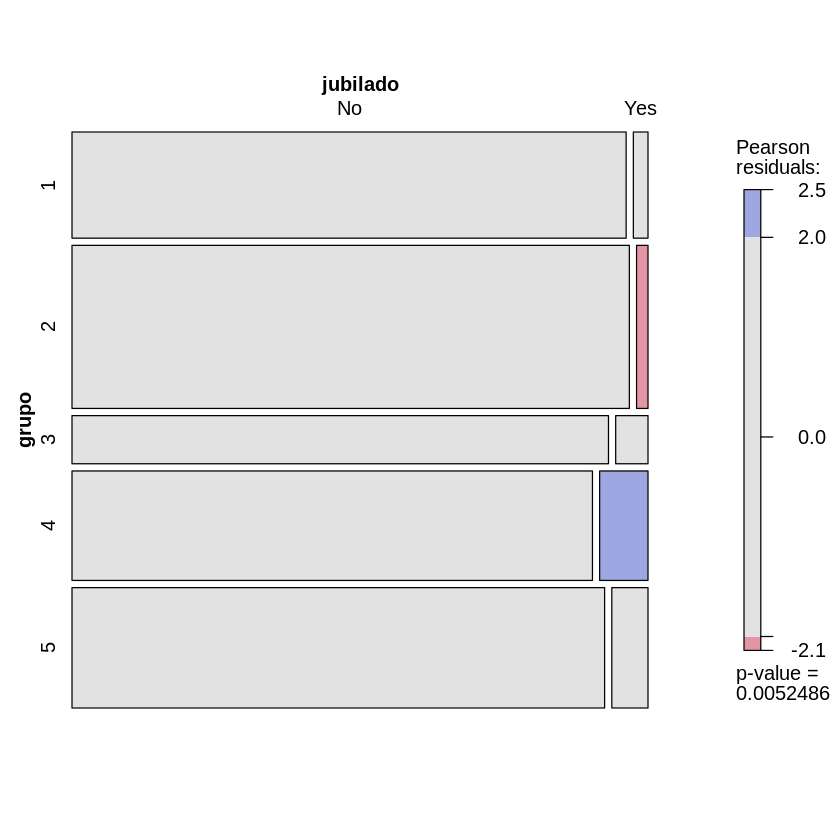

In [27]:
#guardar el cluster de pertenencia
cell$grupo<-cellcluster$cluster
library("vcd")
mosaic(~grupo + jubilado ,data=cell, 
       legend=TRUE, shade=TRUE)

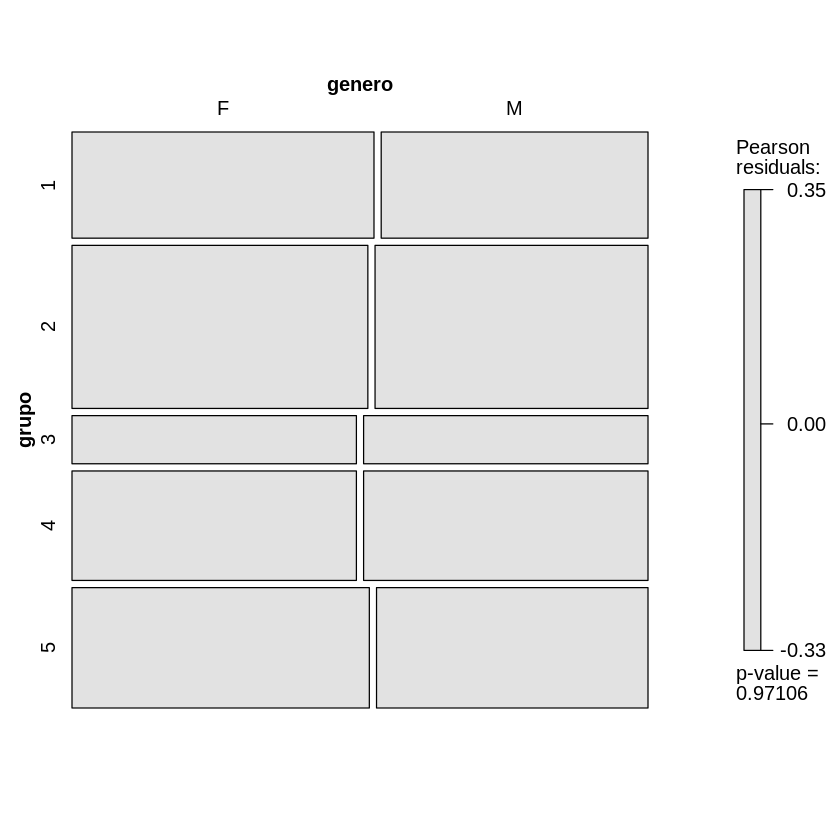

In [28]:
mosaic(~grupo + genero ,data=cell, 
       legend=TRUE, shade=TRUE)

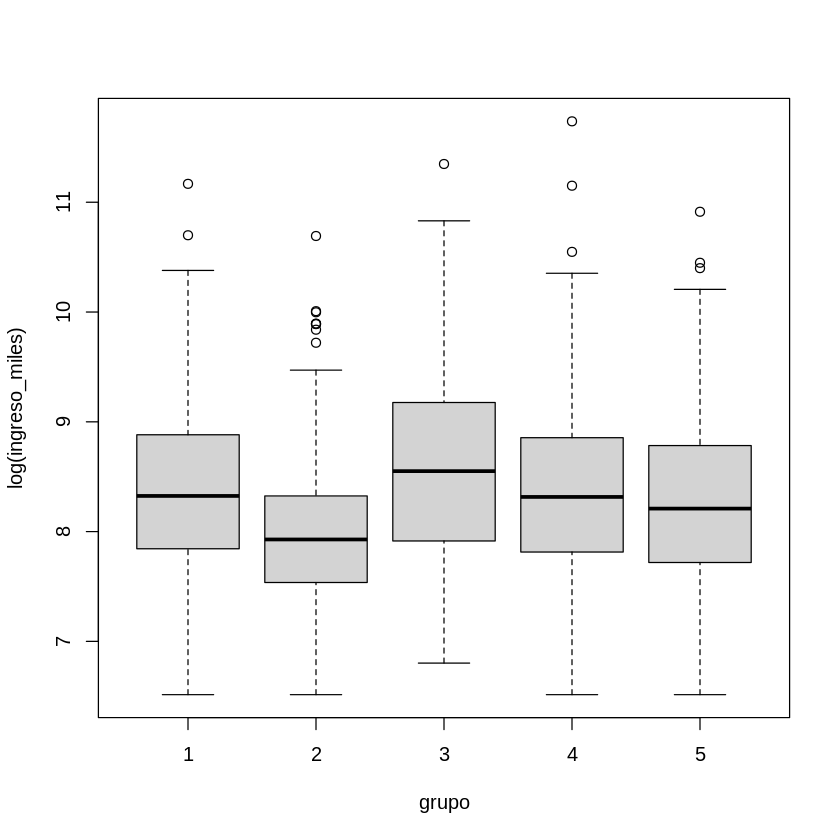

In [29]:
boxplot(log(ingreso_miles)~grupo, data=cell)

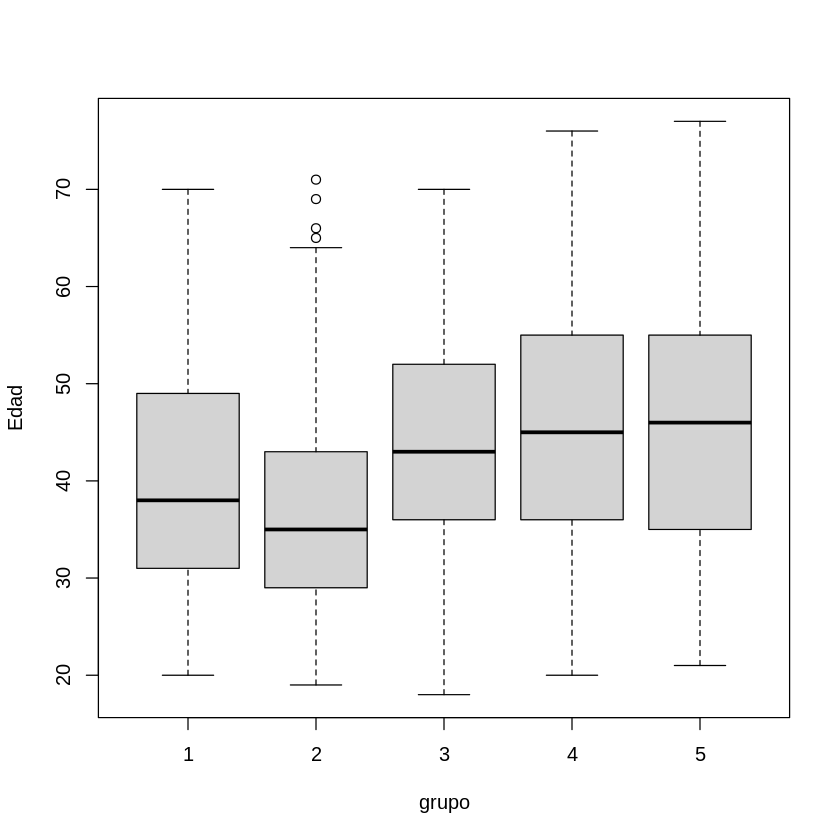

In [30]:
boxplot(Edad~grupo, data=cell)

No se observan diferencias por género. Se observa que los jubilados tienden a estar en el grupo 4 y no en el grupo 3. Así mismo en el grupo 3 están los más jóvenes (lo cual coincide) y los grupos 1 y 5 son los de mayores ingresos (y, por tanto, mayor consumo).

El gráfico a continuación permite ver los clientes proyectados en sus dos dimensiones principales (mediante componentes principales), lo que permitiría explicar o visualizar parcialmente los grupos

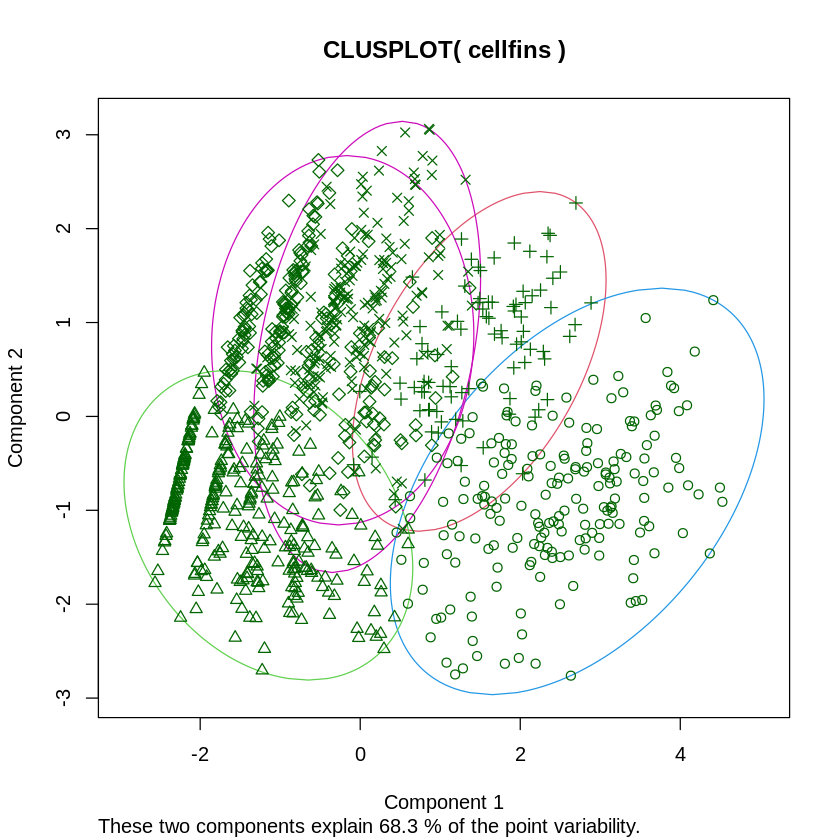

In [31]:
clusplot(cellfins,cellcluster$cluster, color=TRUE)

Para validar los resultados, una opción indirecta es calcular la robustez, en este caso vista como qué tanto variarían los resultados ante pequeñas modificaciones en los datos. Para ello usamos clusterboot.

In [32]:
#validar resultados- consistencia
kclusters <- clusterboot(cellfins,B=10,clustermethod=kmeansCBI,k=5,seed=5)
#la validacion del resultado. >0.75 o .85 muy bueno; <.6 malo
kclusters$bootmean


boot 1 
boot 2 
boot 3 
boot 4 
boot 5 
boot 6 
boot 7 
boot 8 
boot 9 
boot 10 


[1] 0.8187790 0.8883739 0.2469522 0.8413534 0.6829800

Los resultados muestran 3 clusteres bastante coherentes, un grupo en niveles intermedios, y un grupo de coherencia baja, lo que puede sugerir explorar la opción de 4 clústeres. 